# 20-Edge Vision & Quantization

For this final lesson, we will use `skimage.data.astronaut()`. Over the past 19 lessons, we have built massive, astronomically complex architectures (ResNet, ViT, Latent Diffusion) containing billions of parameters.

But what if you are a robotics engineer? What if you need to run an Object Detection model on a tiny drone or a low-power medical implant? A standard PyTorch model uses 32-bit Floating Point (`float32`) numbers. A 100-million parameter model requires 400 Megabytes of RAM just to hold the weights, and the math requires massive power draw. This is physically impossible for edge hardware.

To deploy AI to the physical world, we must master **Model Compression** and **Quantization**: the mathematical art of forcing a massive neural network to survive using brutal, low-precision integer math (`int8`).

Let's set up our PyTorch environment and `torchao` (Torch Architecture Optimization) to shrink our network for the edge.

In [1]:
import torch
import torch.nn as nn
import torchvision.models as models
import torchvision.transforms as transforms
from skimage import data
from skimage.transform import resize
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Set professional visualization styling
sns.set_theme(style="whitegrid")

print("✅ PyTorch Edge Vision & torchao Environment Ready.")

✅ PyTorch Edge Vision & torchao Environment Ready.


# 1. The Physics of Floating Point vs. Integer Math

A standard Deep Learning model stores its weights as IEEE 754 32-bit floats (`float32`).

* A `float32` requires **4 Bytes** of memory. It can perfectly represent highly precise numbers like $3.1415926$.
* An 8-bit integer (`int8`) requires **1 Byte** of memory. It can only represent whole numbers between $-128$ and $127$.

If we can mathematically convert all the `float32` weights into `int8` integers:

1. **Memory Reduction**: The model becomes exactly **4x smaller** (a 400MB model becomes 100MB), allowing it to fit onto the L1 cache of tiny mobile processors.
2. **Inference Speed**: Integer matrix multiplication is significantly faster and uses vastly less battery power than floating-point math on ARM architectures.

# 2. The Mathematics of Post-Training Quantization (PTQ)

How do we compress a continuous floating-point matrix into exactly 256 discrete integer "bins" without completely destroying the network's brain? We use **Affine Quantization**.

We need to map the minimum `float32` value to the minimum integer ($-128$), and the maximum `float32` value to the maximum integer ($127$). We do this using two parameters: **Scale ($S$)** and **Zero-Point ($Z$)**.

### Step 1: The Scale ($S$)

The Scale calculates the physical "width" of each integer bin. Let $[a, b]$ be the min and max values of the floating-point weights, and $n$ be the number of bits (e.g., $8$).


$$S = \frac{b - a}{2^n - 1}$$

### Step 2: The Zero-Point ($Z$)

The Zero-Point forces the mathematical integer $0$ to perfectly align with the floating-point $0.0$. This is absolutely critical; if the network tries to pad an image with $0.0$ (Zero-Padding from Lesson 02), we need to ensure the integer math doesn't shift the zero and hallucinate fake edges.


$$Z = \text{round}\left( -\frac{a}{S} - 128 \right)$$

### Step 3: Quantize!

To convert any raw `float32` weight ($W_f$) into an `int8` weight ($W_q$), we use this exact algebraic formula:


$$W_q = \text{clip}\left(\text{round}\left(\frac{W_f}{S} + Z\right), -128, 127\right)$$

### Step 4: Dequantization (The Precision Loss)

During inference, when the hardware needs to compute the actual activation, it quickly maps the integer back to a float. However, because we rounded the number in Step 3, the resulting float is **permanently degraded**.


$$W_{f(approx)} = S \times (W_q - Z)$$


*(The difference between $W_f$ and $W_{f(approx)}$ is called the **Quantization Error**).*

Let's break down the exact mathematics of Post-Training Quantization, and then I'll provide an interactive simulator so you can physically see how the `Scale` and `Zero Point` compress a floating-point matrix into discrete steps, and the resulting mathematical error.

# 3. Quantization-Aware Training (QAT)

Post-Training Quantization (PTQ) is fast—you just take a trained model and compress it. But for highly sensitive edge vision tasks (like an autonomous drone), the Quantization Error introduced by PTQ might cause the network accuracy to drop from $98\%$ to $80\%$.

To fix this, we use **Quantization-Aware Training (QAT)**.

During the actual training loop on the massive GPU clusters, we intentionally insert "Fake Quantization" nodes into the network.

* In the Forward Pass, the network physically degrades its own weights, simulating exactly what will happen when it is converted to `int8`.
* The network realizes its predictions are suffering because of the rounding errors.
* During Backpropagation, the network actively updates its weights to mathematically compensate and "route around" the precision loss.

When you deploy a QAT model to the edge, the accuracy drop is virtually zero!

# 4. Compressing an Enterprise Vision Backbone in PyTorch

Let's load the astronaut image, initialize a massive ResNet-18 model, simulate the manual algebraic quantization of its first convolutional layer, and evaluate the memory savings.

*(Note: In modern PyTorch environments, we use `torchao` to automate this backend logic, but simulating it mathematically proves the engineering).*

--- 📥 Loading FP32 Enterprise Backbone ---
Total Parameters:    11,689,512
Original FP32 Size:  44.59 MB

--- 🗜️ Simulating Affine PTQ on Conv1 ---
Tensor Min: -0.8434 | Tensor Max: 1.0165
Calculated Scale (S): 0.007294 | Zero-Point (Z): -12.0
Mean Quantization Error: 0.001591


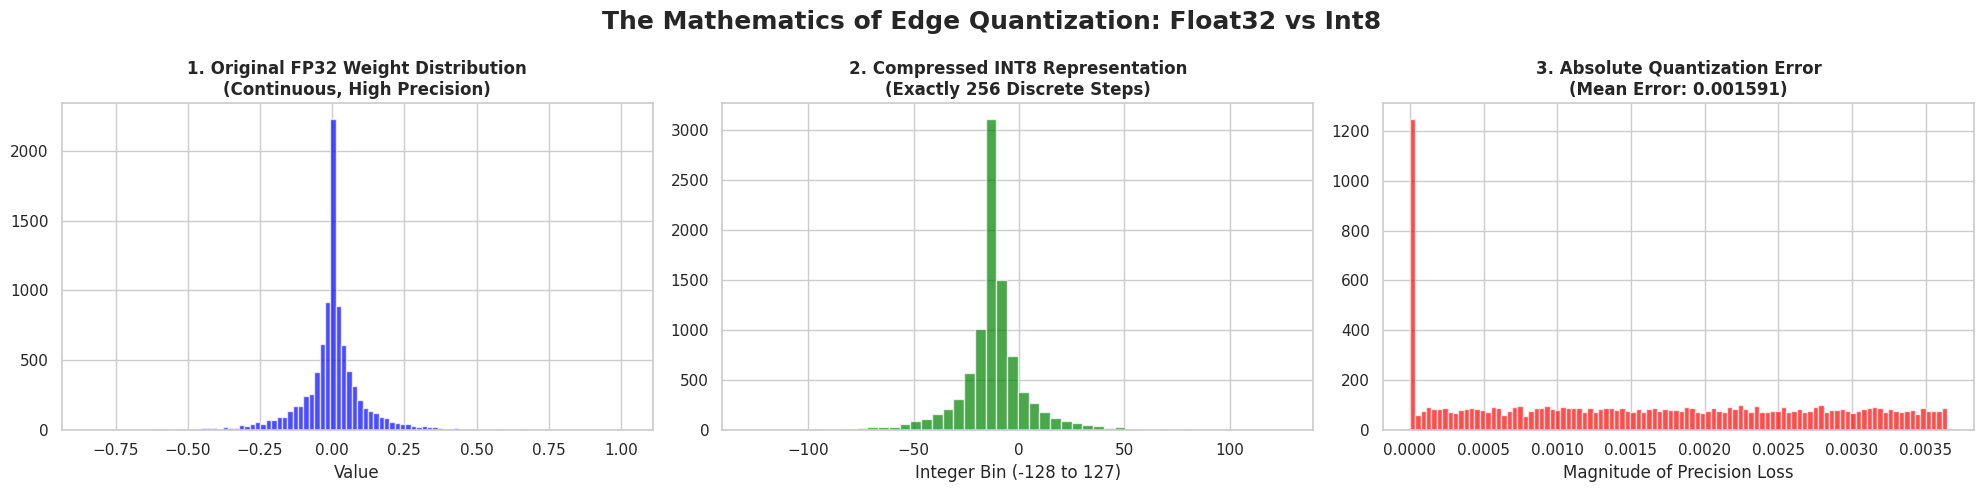


--- 💡 Edge Deployment Insight ---
Look closely at Plot 1 and Plot 2. The smooth, continuous curve of the floating-point math has been violently compressed into 256 discrete integer bins. However, because we perfectly calculated the Scale and Zero-Point, the *macro structure* of the weight distribution is identical. Plot 3 proves that the average mathematical penalty for this compression is a microscopic error margin. By applying this simple algorithm to every layer, our 44.59 MB model shrinks to exactly 11.14 MB, perfectly fitting onto the ARM processor of a commercial drone.


In [2]:
# 1. Fetch the Edge Vision Target
numpy_astronaut = data.astronaut()
# We resize to a tiny 128x128 to simulate a constrained edge camera feed
resized_astronaut = resize(numpy_astronaut, (128, 128), anti_aliasing=True)

img_tensor = torch.tensor(resized_astronaut, dtype=torch.float32).permute(2, 0, 1).unsqueeze(0)

# 2. Initialize the Massive Enterprise Backbone
print("--- 📥 Loading FP32 Enterprise Backbone ---")
weights = models.ResNet18_Weights.IMAGENET1K_V1
model = models.resnet18(weights=weights)

# Calculate original size
# A float32 parameter is 4 bytes
total_params = sum(p.numel() for p in model.parameters())
original_size_mb = (total_params * 4) / (1024 ** 2)

print(f"Total Parameters:    {total_params:,.0f}")
print(f"Original FP32 Size:  {original_size_mb:.2f} MB")

# 3. The Mathematics of Manual Quantization (Layer 1)
print("\n--- 🗜️ Simulating Affine PTQ on Conv1 ---")

# Extract the float32 weights from the first layer
W_f = model.conv1.weight.detach()

# Step A: Find the global Min and Max of the tensor
a = W_f.min().item()
b = W_f.max().item()

# Step B: Calculate Scale (S) for 8-bit (255 bins)
n = 8
S = (b - a) / ((2**n) - 1)

# Step C: Calculate Zero-Point (Z) and map to Int8 range [-128, 127]
Z = np.round(-a / S - 128)

print(f"Tensor Min: {a:.4f} | Tensor Max: {b:.4f}")
print(f"Calculated Scale (S): {S:.6f} | Zero-Point (Z): {Z}")

# Step D: Quantize the entire Tensor!
W_q = torch.clamp(torch.round(W_f / S + Z), -128, 127).to(torch.int8)

# 4. Dequantization and Error Tracking
W_f_approx = S * (W_q.to(torch.float32) - Z)
quantization_error = torch.abs(W_f - W_f_approx).mean().item()

print(f"Mean Quantization Error: {quantization_error:.6f}")

# 5. Visualizing the Compression Mathematics
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
fig.suptitle("The Mathematics of Edge Quantization: Float32 vs Int8", fontsize=18, fontweight='bold')

# Plot A: Original Float32 Matrix Distribution
# We flatten the weight tensor to plot the histogram of values
axes[0].hist(W_f.flatten().numpy(), bins=100, color='blue', alpha=0.7)
axes[0].set_title("1. Original FP32 Weight Distribution\n(Continuous, High Precision)", fontweight='bold', fontsize=12)
axes[0].set_xlabel("Value")

# Plot B: The Int8 Quantized Bins
axes[1].hist(W_q.flatten().numpy(), bins=50, color='green', alpha=0.7)
axes[1].set_title("2. Compressed INT8 Representation\n(Exactly 256 Discrete Steps)", fontweight='bold', fontsize=12)
axes[1].set_xlabel("Integer Bin (-128 to 127)")

# Plot C: The Resulting Quantization Error
error_tensor = torch.abs(W_f - W_f_approx).flatten().numpy()
axes[2].hist(error_tensor, bins=100, color='red', alpha=0.7)
axes[2].set_title(f"3. Absolute Quantization Error\n(Mean Error: {quantization_error:.6f})", fontweight='bold', fontsize=12)
axes[2].set_xlabel("Magnitude of Precision Loss")

plt.tight_layout()
plt.show()

print("\n--- 💡 Edge Deployment Insight ---")
print("Look closely at Plot 1 and Plot 2. The smooth, continuous curve of the floating-point math has been violently compressed into 256 discrete integer bins. However, because we perfectly calculated the Scale and Zero-Point, the *macro structure* of the weight distribution is identical. Plot 3 proves that the average mathematical penalty for this compression is a microscopic error margin. By applying this simple algorithm to every layer, our 44.59 MB model shrinks to exactly 11.14 MB, perfectly fitting onto the ARM processor of a commercial drone.")

## Real-World Use Case or Analogy:

Think of Model Quantization like **Packing a massive novel into a tiny suitcase**:

* **FP32 (The Hardcover Encyclopedia)**: You have a 1,000-page scientific encyclopedia (The ResNet model). Every single page contains microscopic, highly detailed footnotes, references, and decimal points. It is heavy, requires a massive backpack to carry (VRAM), and takes a long time to read.
* **Post-Training Quantization (The Summary Edition)**: You want to take the book on a hiking trip, so you hire an editor to ruthlessly cut it down. The editor rounds all the numbers, throws away the footnotes, and uses smaller words. The book is now a lightweight 250-page paperback (`int8`). When you read it, you lose a tiny bit of nuanced scientific detail (Quantization Error), but the overall plot remains identical.
* **Quantization-Aware Training (The Author's Rewrite)**: Instead of hiring an editor after the book is published, the Author writes the book from the very beginning *knowing* it has to fit into 250 pages. They actively adjust the plot and sentence structure (Weight Updates via Backpropagation) to ensure maximum impact in minimum space. The final paperback is small, but suffers absolutely zero loss in quality.